<a href="https://colab.research.google.com/github/wasimnawaz1/NLP_lectures/blob/main/Introduction_to_NLP_(Week_6)_Autocorrect_MinEditDistance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS438  Natural Language Processing (NLP)** (Week 6)
https://github.com/wasimnawaz1/NLP_lectures

## Instructor: Dr. M. Wasim Nawaz (Associate Professor, Artificial Intelligence)
    📞+92-331-4180565  📧 wasim.nawaz@umt.edu.pk

Office: SST 1 - 506
Office Hours (Ramadan): 09:00 am to 10:00 am (Monday to Friday)

Office Hours: 10:00 am to 12:00 pm (Monday to Friday)



### This notebook covers Autocorrect & Minimum Edit Distance



### What is Autocorrect?

Autocorrect is used on **phones, tablets, and computers** to automatically fix misspelled words.


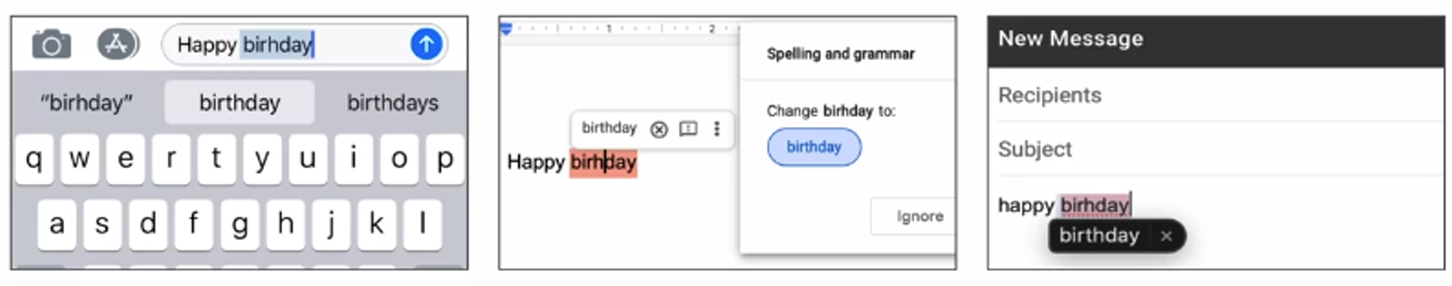


### Autocorrect Example

| Input | Corrected |
|---|---|
| `Happy birthday deah friend! 🎂` | `Happy birthday dear friend! 🎂` ✅ |
| `Happy birthday deer friend! 🦌` | ❌ not corrected — *deer* is a valid word! |

### How Autocorrect Works — 4 Steps

| Step | Action | Example (`deah`) |
|---|---|---|
| 1 | **Identify** a misspelled word | `deah` → not in dictionary ❌ |
| 2 | **Find** strings *n* edit distance away | `_eah`, `d_ar`, `de_r`, … |
| 3 | **Filter** candidates (keep valid words) | `yeah`, `dear`, `dean`, … |
| 4 | **Calculate** word probabilities & pick best | `dear` ✅ (highest P) |

### Building the Autocorrect Model

#### Step 1 — Identify Misspelled Words

A word is considered **misspelled** if it does **not** appear in your vocabulary/dictionary.

| Word | In dictionary? | Decision |
|---|---|---|
| `deah` | No | ❌ Misspelled |
| `deer` | Yes | ✅ Accepted (even if contextually wrong) |

#### Step 2 — Find Strings *n* Edit Distances Away

An **edit** is any single operation performed on a string to change it:

| Operation | Description | Example |
|---|---|---|
| **Insert** | Add a letter | `'to'` → `'top'`, `'two'` |
| **Delete** | Remove a letter | `'hat'` → `'ha'`, `'at'`, `'ht'` |
| **Switch** | Swap 2 **adjacent** letters | `'eta'` → `'eat'`, `'tea'` |
| **Replace** | Change 1 letter to another | `'jaw'` → `'jar'`, `'paw'` |

> ⚠️ **Switch** only works on **adjacent** letters — `'eta'` → `'ate'` requires 2 switches and is **not** 1 edit.

#### Step 3 — Filter Candidates

After generating all strings *n* edits away, keep only those that appear in the dictionary:

| Generated string | Valid word? |
|---|---|
| `deah` | ❌ |
| `_eah` | ❌ |
| `yeah` | ✅ |
| `dear` | ✅ |
| `dean` | ✅ |

#### Step 4 — Calculate Word Probabilities

The probability of a word is estimated from a **corpus** (large text dataset):

$$P(w) = \frac{\text{count}(w)}{\text{total words in corpus}}$$

**Example corpus:** `"I am happy because I am learning"`

| Word | Count | Probability |
|---|---|---|
| I | 2 | 2/7 ≈ 0.286 |
| am | 2 | 2/7 ≈ 0.286 |
| happy | 1 | 1/7 ≈ 0.143 |
| because | 1 | 1/7 ≈ 0.143 |
| learning | 1 | 1/7 ≈ 0.143 |
| **Total** | **7** | **1.0** |

The candidate word with the **highest probability** wins → `dear` ✅

### Autocorrect Summary

```
Input: "deah"

Step 1 → deah not in dictionary ❌
Step 2 → Insert/Delete/Switch/Replace → {yeah, dear, dean, …}
Step 3 → Filter to valid dictionary words
Step 4 → P(dear) > P(yeah) > P(dean) → output: dear ✅
```

### Minimum Edit (Levenshtein) Distance

**Minimum edit distance** measures how similar two strings are by counting the **minimum number of single-character edits (insertions, deletions or substitutions)** needed to transform one string into the other.

**Applications:**
- **Spell checking** — finding the closest dictionary word to a misspelled input
- **Plagiarism detection**
- **Machine translation evaluation** — measuring how different a translated sentence is from a reference
- **DNA sequence comparison** in computational biology

The three allowed edit operations are: **Insert**, **Delete**, **Replace/Substitute**  


### Edit Costs (Levenshtein Variant)

| Operation | Cost |
|---|---|
| Insert | 1 |
| Delete | 1 |
| Replace/Substitute | **2** |

> Sometimes, a replace cost = 1 is used. Here replace = delete + insert = 2.

### Application 1 — Spell Correction

A user types **"recieve"**. Possible corrections: `receive`, `recipe`, `relieve`, `deceive`.

MED tells us which correction requires the **fewest edits** — that is the most likely intended word.

| Hypothesis | Operations |
|------------|------------|
| receive | swap i↔e (1 substitution) |
| recipe | multiple substitutions |
| deceive | multiple substitutions |

### Application 2 — Computational Biology

MED is used to **align DNA sequences** by matching each base letter to a letter or a gap (`-`).

```
Seq 1:  AGGCTATCACCTGACCT--CCAGGCCGA
Seq 2:  TAGCTATCAC--GACCGCGTGGCCGATTG
```

The alignment that minimises total insertions/deletions/substitutions gives the **evolutionary distance** between two sequences.

### Example: `play` → `stay`

| Source | Target | Operation | Cost |
|---|---|---|---|
| `p` | `s` | Replace | 2 |
| `l` | `t` | Replace | 2 |
| `a` | `a` | Match | 0 |
| `y` | `y` | Match | 0 |

**Total edit distance = 4** (2 replacements × cost 2)

### Minimum Edit Distance (Recurrence Formula)

$$
\operatorname{lev}(a,b) =
\begin{cases}
|a| & \text{if } |b| = 0  ( \text{all deletions}) \\
|b| & \text{if } |a| = 0  ( \text{all insertions})\\
\operatorname{lev}(a[1:], b[1:]) & \text{if } a[0] = b[0]  (\text{recurse on remaining strings})\\
\min\Bigg(
\operatorname{1 + lev}(a[1:], b),   \\
\operatorname{1 + lev}(a, b[1:]),    \\
\operatorname{2 + lev}(a[1:], b[1:])
\Bigg) & \text{otherwise}
\end{cases}
$$

* The recurrence defines the **Levenshtein (edit) distance** between two strings ($a$) and ($b$) as:

  * The **minimum number of operations** required to transform ($a$) into ($b$)


* If first characters differ (Mismatch Case - Last Line), consider three operations and take minimum:
  * **Deletion** of first character of $a$:  ${lev}(a[1:], b)$
  * **Insertion** of a character into ($a$): ${lev}(a, b[1:])$
  * **Replacement** of first character of ($a$): ${lev}(a[1:], b[1:])$

### Example

* **Given:**   $a = \text{"cat"}$ and   $b = \text{"cut"}$

- Step 1: Compare first characters
    * $c = c$ → match
    * Reduce problem: $\operatorname{lev}(\text{"at"}, \text{"ut"})$

- **Step 2: Characters differ**
  * $a \ne u$, try all operations:

    * **Delete** (remove `'a'` from $a$):  $1 + \operatorname{lev}(\text{"t"}, \text{"ut"})$
    * **Insert** (insert `'u'` into $a$):  $1 + \operatorname{lev}(\text{"at"}, \text{"t"})$
    * **Replace** (`'a' to 'u'`):  $ 2 + \operatorname{lev}(\text{"t"}, \text{"t"})$

- **Step 3: Solve subproblems**

  * $\operatorname{lev}(\text{"t"}, \text{"ut"}) = 1$ (insert `'u'`)
  * $\operatorname{lev}(\text{"at"}, \text{"t"}) = 1$ (delete `'a'`)
  * $\operatorname{lev}(\text{"t"}, \text{"t"}) = 0$

- **Step 4: Compute total costs**

  * **Delete:** $1 + 1 = 2$
  * **Insert:** $1 + 1 = 2$
  * **Replace:** $2 + 0 = 2$

  $$
  \mathbf{\operatorname{lev}(\text{"cat"}, \text{"cut"}) = 2}
  $$

  ✔ All operations give equal cost  
  ✔ One optimal solution: Replace `'a' \to 'u'`(assuming replacement cost =2)







### Recursive Calls (Expensive Operation)

When the length of strings/words to be matched, increases, the cost of recursive calls increases significantlly due to overlapping problems.


> **Given:**   $a = \text{"play"}$ and   $b = \text{"stay"}$

```
lev(play, stay)
│
├── lev(lay, stay)            (delete 'p')
│   │
│   ├── lev(ay, stay)
│   │   │
│   │   ├── lev(y, stay)
│   │   │   └── ...
│   │   │
│   │   ├── lev(ay, tay)
│   │   │   └── ...
│   │   │
│   │   └── lev(y, tay)
│   │       └── ...
│   │
│   ├── lev(lay, tay)
│   │   │
│   │   ├── lev(ay, tay)
│   │   │   └── ...
│   │   │
│   │   ├── lev(lay, ay)
│   │   │   └── ...
│   │   │
│   │   └── lev(ay, ay)
│   │       │
│   │       └── lev(y, y)
│   │           │
│   │           └── lev("", "") = 0
│   │
│   └── lev(ay, tay)
│       └── ...
│
├── lev(play, tay)            (insert 's')
│   │
│   ├── lev(lay, tay)
│   │   │
│   │   ├── lev(ay, tay)
│   │   │   └── ...
│   │   │
│   │   ├── lev(lay, ay)
│   │   │   └── ...
│   │   │
│   │   └── lev(ay, ay)
│   │       │
│   │       └── lev(y, y)
│   │           └── lev("", "") = 0
│   │
│   ├── lev(play, ay)
│   │   │
│   │   ├── lev(lay, ay)
│   │   │   └── ...
│   │   │
│   │   ├── lev(play, y)
│   │   │   └── ...
│   │   │
│   │   └── lev(lay, y)
│   │       └── ...
│   │
│   └── lev(lay, ay)
│       └── ...
│
└── lev(lay, tay)             (replace 'p' → 's')
    │
    ├── lev(ay, tay)
    │   │
    │   ├── lev(y, tay)
    │   │   └── ...
    │   │
    │   ├── lev(ay, ay)
    │   │   │
    │   │   └── lev(y, y)
    │   │       └── lev("", "") = 0
    │   │
    │   └── lev(y, ay)
    │       └── ...
    │
    ├── lev(lay, ay)
    │   │
    │   ├── lev(ay, ay)
    │   │   └── lev(y, y) → lev("", "") = 0
    │   │
    │   ├── lev(lay, y)
    │   │   └── ...
    │   │
    │   └── lev(ay, y)
    │       └── ...
    │
    └── lev(ay, ay)
        │
        └── lev(y, y)
            │
            └── lev("", "") = 0
```


### Minimum Edit Distance Algorithm (Dynamic Programming)

Exhaustive search using recursion is computationally exponential.

**Dynamic programming (DP)** is faster than recursive approach.
- DP solves MED in $O(m \times n)$ time by building a table $D(i,j)$.
- $D(i,j)$ = edit distance between the first $i$ characters of source and first $j$ characters of target.
- Building DP table and computing MED is the **Levenshtein / Wagner-Fischer** algorithm.


#### Notation

| Symbol | Meaning |
|---|---|
| `src` | The original string (rows) |
| `tar` | The string to transform to (columns) |
| `D[i, j]` | Min edit distance from `src[:i]` to `tar[:j]` |
| `D[m, n]` | Final answer: full `src` → full `tar` |
| `#` | Empty string (row/column 0) |

### Minimum Edit Distance (Dynamic Programming Formula)

Let $i = 1 \ldots m$, $j = 1 \ldots n$, where $m$ is the length of source word $src$ and $n$ is length of target word $tar$.


The minimum edit distance $D[i,j]$ between the first $i$ characters of source and first $j$ characters of target can be given as:

$$D[i,j] = \min \begin{cases} D[i-1,\, j] + \text{del_cost} \\ D[i,\, j-1] + \text{ins_cost} \\ D[i-1,\, j-1] + \text{rep_cost} & \text{if } src[i] \neq tar[j] \\ D[i-1,\, j-1] + 0 & \text{if } src[i] = tar[j] \end{cases}$$

### Minimum Edit Distance Algorithm (Dynamic Programming Table)

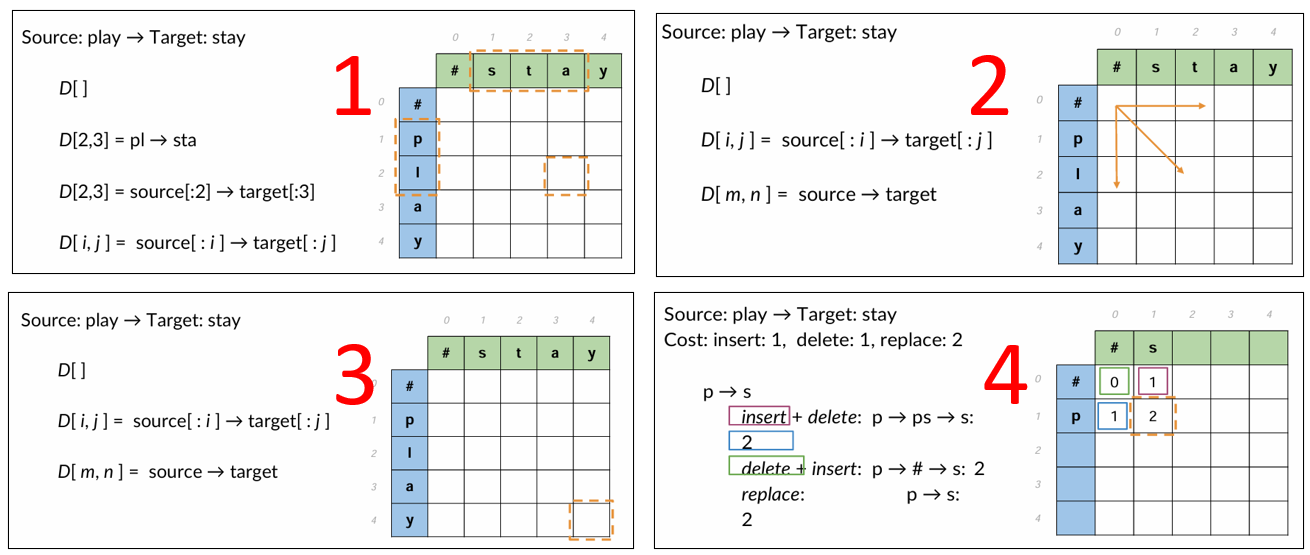

### Minimum Edit Distance Algorithm (Dynamic Programming)

| Direction | Operation | Meaning |
|---|---|---|
| ↓ `D[i-1, j] + del` | Delete from source | Remove `src[i]` |
| → `D[i, j-1] + ins` | Insert into source | Add `tar[j]` |
| ↘ `D[i-1, j-1] + rep/0` | Replace or match | Change `src[i]` to `tar[j]` |

**Termination:** $D(m, n)$ is the final minimum edit distance.

**Initialisation:**
- `D[0, j] = j` — cost of inserting *j* characters into empty string  
- `D[i, 0] = i` — cost of deleting *i* characters to reach empty string
- `D[0, 0]` represents converting to/from the **empty string**.

### Worked Example: `play` → `stay` (costs: ins=1, del=1, rep=2)

How is `D[1,1]` (`p→s`) computed?

Three choices, take the minimum:

| Path | Formula | Value |
|---|---|---|
| Delete `p` | `D[0,1] + 1 = 1 + 1` | **2** |
| Insert `s` | `D[1,0] + 1 = 1 + 1` | **2** |
| Replace `p→s` | `D[0,0] + 2 = 0 + 2` | **2** |
| **min** | | **2** |

All three paths cost 2, so `D[1,1] = 2`.

### Worked Example: `play` → `stay` (costs: ins=1, del=1, rep=2)

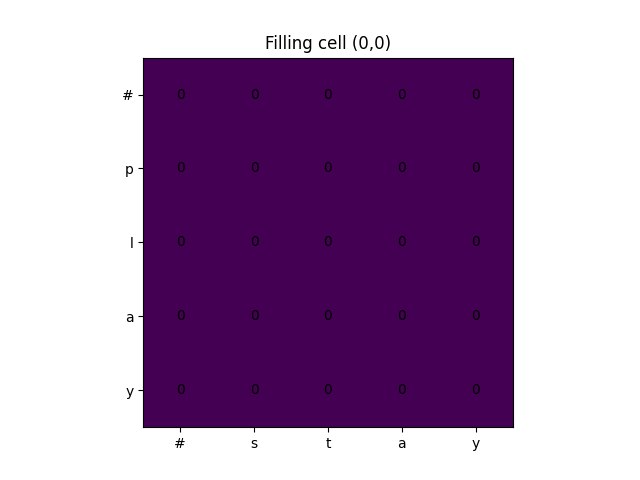

### Worked Example: `play` → `stay` (costs: ins=1, del=1, rep=2)

Filled DP table `D[i,j]`:

| | **#** | **s** | **t** | **a** | **y** |
|---|---|---|---|---|---|
| **#** | 0 | 1 | 2 | 3 | 4 |
| **p** | 1 | 2 | 3 | 4 | 5 |
| **l** | 2 | 3 | 4 | 5 | 6 |
| **a** | 3 | 4 | 5 | 4 | 5 |
| **y** | 4 | 5 | 6 | 5 | **4** |

**Answer: `D[4,4] = 4`** → minimum edit distance from `play` to `stay` is **4**.

### Key Algorithmic Properties

| Property | Description |
|---|---|
| **Levenshtein distance** | The standard name for this measure |
| **Dynamic programming** | Solves overlapping subproblems bottom-up |
| **Backtrace** | Tracing back through the table reveals the actual sequence of edits |
| **Time complexity** | O(m × n) where m, n are string lengths |
| **Space complexity** | O(m × n) for the full table (can be optimised) |

### Homework Example

#### INTENTION → EXECUTION

Align **INTENTION** and **EXECUTION** with `*` marking insertion/deletion points:

```
I N T E * N T I O N
| | | |   | | | | |
* E X E C U T I O N
d s s   i s
```

Operations: `d` = delete, `s` = substitute, `i` = insert

- **Uniform cost (1 per operation):** Distance = **5**
- **Levenshtein (substitution costs 2):** Distance = **8**

### The DP Table — Completed (Levenshtein, sub/rep cost = 2)

The completed table for INTENTION → EXECUTION:

```
     #   E   X   E   C   U   T   I   O   N
#  [ 0   1   2   3   4   5   6   7   8   9 ]
I  [ 1   2   3   4   5   6   7   6   7   8 ]
N  [ 2   3   4   5   6   7   8   7   8   7 ]
T  [ 3   4   5   6   7   8   7   8   9   8 ]
E  [ 4   3   4   5   6   7   8   9  10   9 ]
N  [ 5   4   5   6   7   8   9  10  11  10 ]
T  [ 6   5   6   7   8   9   8   9  10  11 ]
I  [ 7   6   7   8   9  10   9   8   9  10 ]
O  [ 8   7   8   9  10  11  10   9   8   9 ]
N  [ 9   8   9  10  11  12  11  10   9   8 ]
```

**Result: $D(9,9) = 8$** (Levenshtein with substitution cost = 2)

### Backtrace — Recovering the Alignment

After filling the DP table, we **backtrace** from $D(m,n)$ to $D(0,0)$ using pointer arrows stored during the forward pass:

| Pointer | Meaning |
|---------|---------|
| **DIAG** (↖) | Characters matched or substituted |
| **UP** (↑) | Deletion from source |
| **LEFT** (←) | Insertion into source |

The backtrace path gives the **optimal alignment** — the cheapest sequence of operations.


### The completed table for INTENTION → EXECUTION with Backtrace Arrows (intention → execution)

Legend:  
↖ = match / replace  ↑ = delete  ← = insert  
```
     #    E    X    E    C    U    T    I    O    N
#  [ 0    1    2    3    4    5    6    7    8    9 ]
I  [ 1↑   2    3    4    5    6    7    6    7    8 ]
N  [ 2↑    3   4    5    6    7    8    7    8    7 ]
T  [ 3↑   4    5    6    7    8    7    8    9    8 ]
E  [ 4    3↖   4←   5←   6←   7←   8    9   10    9 ]
N  [ 5    4    5    6    7    8↑   9   10   11   10 ]
T  [ 6    5    6    7    8    9    8↖   9   10   11 ]
I  [ 7    6    7    8    9   10    9    8↖   9   10 ]
O  [ 8    7    8    9   10   11   10    9    8↖   9 ]
N  [ 9    8    9   10   11   12   11   10    9    8↖]
```
```
(9,9) ↖ (8,8) --- match N
(8,8) ↖ (7,7) --- match O
(7,7) ↖ (6,6) --- match I
(6,6) ↖ (5,5) --- match T
(5,5) ↑ (4,5) --- delete N
(4,5) ← (4,4) --- insert U
(4,4) ← (4,3) --- insert C
(4,3) ← (4,2) --- insert E
(4,2) ← (4,1) --- insert X
(4,1) ↖ (3,0) --- match E
(3,0) ↖ (2,0) --- delete T
(2,0) ↑ (1,0) --- delete N
(1,0) ↑ (0,0) --- delete I
```

### Backtrace Result — INTENTION ↔ EXECUTION

The backtrace for INTENTION → EXECUTION gives:

```
I N T E * N T I O N
| | | | | | | | | |
* E X E C U T I O N
```

Each aligned column is either a **match** (no cost), **substitution**, **insertion**, or **deletion**.

Substitutions: I→E, N→X, T→E, E→C, N→U. The last four characters TION match exactly.

### MED with Backtrace — Algorithm Overview

The algorithm has two phases:

**Phase 1 — Forward DP:** Fill matrix $D$ (edit distances) and pointer matrix $P$ (where each optimal step came from).

**Phase 2 — Backtrace:** Starting from $D(m,n)$, follow pointers back to $D(0,0)$, appending characters or gaps (`-`) to build aligned sequences.

Finally, reverse both aligned sequences (since they were built backwards) to get the alignment.

### Weighted Edit Distance

In standard MED, all operations cost 1. **Weighted Edit Distance** allows operation-specific costs:

$$D(i,j) = \min \begin{cases} D(i-1,j) + \text{del}[x(i)] \\ D(i,j-1) + \text{ins}[y(j)] \\ D(i-1,j-1) + \text{sub}[x(i), y(j)] \end{cases}$$

This is important in spell correction (some typos more likely than others) and ASR (some phonemes more easily confused than others).

**Termination:** $D(m, n)$ gives the weighted edit distance.

#### Cost Variants Summary

| Variant | ins | del | sub (diff) | sub (same) | Example dist INTENTION→EXECUTION |
|---------|-----|-----|-----------|-----------|----------------------------------|
| **Uniform** | 1 | 1 | 1 | 0 | **5** |
| **Levenshtein** | 1 | 1 | 2 | 0 | **8** |
| **Weighted** | custom | custom | custom | 0 | depends on cost matrix |

### Summary

| Topic | Key Idea |
|---|---|
| Autocorrect | 4 steps: identify → find candidates → filter → rank by probability |
| Edit operations | Insert, Delete, Switch, Replace |
| Word probability | `P(w) = count(w) / corpus_size` |
| Min edit distance | Minimum edits to turn one string into another |
| DP recurrence | `D[i,j] = min(delete, insert, replace/match)` |
| Levenshtein algo | Classic algorithm; backtrace reveals edit path |

---
## Code Implementations

In [ ]:
# ── Step 1: Build vocabulary from a corpus ────────────────────────────────────
import re
from collections import Counter

def build_vocab(corpus: str) -> set:
    """Return the set of unique lowercased words in the corpus."""
    return set(re.findall(r'[a-z]+', corpus.lower()))

corpus = "I am happy because I am learning NLP"
vocab  = build_vocab(corpus)
print("Vocabulary:", vocab)

Vocabulary: {'learning', 'am', 'because', 'happy', 'nlp', 'i'}


In [ ]:
# ── Step 2: Generate all strings 1 edit away ─────────────────────────────────
import string

LETTERS = string.ascii_lowercase

def edits_insert(word):
    """All strings formed by inserting one letter."""
    return {word[:i] + c + word[i:] for i in range(len(word)+1) for c in LETTERS}

def edits_delete(word):
    """All strings formed by deleting one letter."""
    return {word[:i] + word[i+1:] for i in range(len(word))}

def edits_switch(word):
    """All strings formed by swapping two adjacent letters."""
    return {word[:i] + word[i+1] + word[i] + word[i+2:] for i in range(len(word)-1)}

def edits_replace(word):
    """All strings formed by replacing one letter."""
    return {word[:i] + c + word[i+1:] for i in range(len(word)) for c in LETTERS if c != word[i]}

def all_edits_1(word):
    return edits_insert(word) | edits_delete(word) | edits_switch(word) | edits_replace(word)

print(f"1-edit neighbours of 'deah' (sample): {list(all_edits_1('deah'))[:10]}")

In [ ]:
# ── Step 3 & 4: Filter candidates and rank by probability ────────────────────
def word_probs(corpus: str) -> dict:
    words  = re.findall(r'[a-z]+', corpus.lower())
    counts = Counter(words)
    total  = sum(counts.values())
    return {w: c / total for w, c in counts.items()}

# Toy corpus — replace with a real text file for production
toy_corpus = """
the quick brown fox jumps over the lazy dog dear dean yeah bear
year near fear dear dear dear dean dean
"""

probs = word_probs(toy_corpus)
vocab = set(probs.keys())

def autocorrect(word: str, n: int = 1) -> list:
    """Return top-5 corrections for a misspelled word."""
    if word in vocab:
        return [word]  # already correct
    candidates = all_edits_1(word) & vocab
    if not candidates and n == 2:
        candidates = {e2 for e1 in all_edits_1(word) for e2 in all_edits_1(e1)} & vocab
    ranked = sorted(candidates, key=lambda w: probs.get(w, 0), reverse=True)
    return ranked[:5]

print("Corrections for 'deah':", autocorrect('deah'))

In [ ]:
# ── Minimum Edit Distance (Levenshtein DP) ───────────────────────────────────
import numpy as np

def min_edit_distance(source: str, target: str,
                      ins_cost: int = 1,
                      del_cost: int = 1,
                      rep_cost: int = 2) -> tuple:
    """
    Compute minimum edit distance between source and target.
    Returns (distance, D_matrix).
    """
    m, n = len(source), len(target)
    D = np.zeros((m+1, n+1), dtype=int)

    # Initialise borders
    D[:, 0] = np.arange(m+1) * del_cost   # delete all source chars
    D[0, :] = np.arange(n+1) * ins_cost   # insert all target chars

    for i in range(1, m+1):
        for j in range(1, n+1):
            r = 0 if source[i-1] == target[j-1] else rep_cost
            D[i, j] = min(
                D[i-1, j] + del_cost,    # delete
                D[i, j-1] + ins_cost,    # insert
                D[i-1, j-1] + r          # replace / match
            )
    return D[m, n], D


dist, D = min_edit_distance('play', 'stay')
print(f"min_edit_distance('play', 'stay') = {dist}")
print()

# Pretty-print the DP table
import pandas as pd
source, target = 'play', 'stay'
rows = ['#'] + list(source)
cols = ['#'] + list(target)
df   = pd.DataFrame(D, index=rows, columns=cols)
print(df)

In [ ]:
# ── Backtrace: recover the actual edit operations ────────────────────────────
def backtrace(source: str, target: str, D: np.ndarray,
              ins_cost=1, del_cost=1, rep_cost=2) -> list:
    """Walk back through D to find the sequence of edits."""
    i, j = len(source), len(target)
    ops   = []
    while i > 0 or j > 0:
        if i > 0 and D[i,j] == D[i-1,j] + del_cost:
            ops.append(f"Delete '{source[i-1]}' (pos {i-1})")
            i -= 1
        elif j > 0 and D[i,j] == D[i,j-1] + ins_cost:
            ops.append(f"Insert '{target[j-1]}' (pos {j-1})")
            j -= 1
        else:
            if source[i-1] != target[j-1]:
                ops.append(f"Replace '{source[i-1]}' → '{target[j-1]}'")
            else:
                ops.append(f"Keep '{source[i-1]}'")
            i -= 1; j -= 1
    ops.reverse()
    return ops

ops = backtrace('play', 'stay', D)
print("Edit operations:")
for op in ops:
    print(" ", op)

In [ ]:
# ── Visualise the DP table as a heatmap ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_dp_table(source, target, D):
    fig, ax = plt.subplots(figsize=(len(target)+1.5, len(source)+1.5))
    cmap = plt.cm.Blues
    im   = ax.imshow(D, cmap=cmap, aspect='auto')

    # Annotate cells
    for i in range(D.shape[0]):
        for j in range(D.shape[1]):
            ax.text(j, i, str(D[i,j]), ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if D[i,j] > D.max()/2 else 'black')

    # Labels
    ax.set_xticks(range(len(target)+1))
    ax.set_xticklabels(['#'] + list(target), fontsize=13)
    ax.set_yticks(range(len(source)+1))
    ax.set_yticklabels(['#'] + list(source), fontsize=13)
    ax.xaxis.tick_top()

    ax.set_title(f"Min Edit Distance DP Table: '{source}' → '{target}'  (D[m,n]={D[-1,-1]})",
                 fontsize=12, pad=20)
    plt.colorbar(im, ax=ax, fraction=0.03)
    plt.tight_layout()
    plt.show()

plot_dp_table('play', 'stay', D)

In [ ]:
# ── Test on more examples ─────────────────────────────────────────────────────
examples = [
    ('deah', 'dear'),
    ('intention', 'execution'),
    ('kitten', 'sitting'),
    ('to', 'go'),
]

print(f"{'Source':<15} {'Target':<15} {'Distance':>10}")
print("-" * 42)
for src, tgt in examples:
    d, _ = min_edit_distance(src, tgt)
    print(f"{src:<15} {tgt:<15} {d:>10}")